In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

%matplotlib notebook
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np 
import pandas as pd 
import warnings
warnings.filterwarnings('ignore')

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
        

# You can write up to 5GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/factors-affecting-campus-placement/Placement_Data_Full_Class.csv


In [2]:
data=pd.read_csv('/kaggle/input/factors-affecting-campus-placement/Placement_Data_Full_Class.csv')
data.drop('sl_no',axis=1,inplace=True)
data.head()

,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed,270000.0
1,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed,200000.0
2,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed,250000.0
3,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,Not Placed,NaN
4,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed,425000.0


# Exploratory Data Analysis

In [3]:
data.shape

(215, 14)

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 215 entries, 0 to 214
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   gender          215 non-null    object 
 1   ssc_p           215 non-null    float64
 2   ssc_b           215 non-null    object 
 3   hsc_p           215 non-null    float64
 4   hsc_b           215 non-null    object 
 5   hsc_s           215 non-null    object 
 6   degree_p        215 non-null    float64
 7   degree_t        215 non-null    object 
 8   workex          215 non-null    object 
 9   etest_p         215 non-null    float64
 10  specialisation  215 non-null    object 
 11  mba_p           215 non-null    float64
 12  status          215 non-null    object 
 13  salary          148 non-null    float64
dtypes: float64(6), object(8)
memory usage: 23.6+ KB


In [5]:
data.describe()

,ssc_p,hsc_p,degree_p,etest_p,mba_p,salary
count,215.000000,215.000000,215.000000,215.000000,215.000000,148.000000
mean,67.303395,66.333163,66.370186,72.100558,62.278186,288655.405405
std,10.827205,10.897509,7.358743,13.275956,5.833385,93457.452420
min,40.890000,37.000000,50.000000,50.000000,51.210000,200000.000000
25%,60.600000,60.900000,61.000000,60.000000,57.945000,240000.000000
50%,67.000000,65.000000,66.000000,71.000000,62.000000,265000.000000
75%,75.700000,73.000000,72.000000,83.500000,66.255000,300000.000000
max,89.400000,97.700000,91.000000,98.000000,77.890000,940000.000000


In [6]:
data.isnull().sum()

gender             0
ssc_p              0
ssc_b              0
hsc_p              0
hsc_b              0
hsc_s              0
degree_p           0
degree_t           0
workex             0
etest_p            0
specialisation     0
mba_p              0
status             0
salary            67
dtype: int64

In [7]:
data.status.value_counts()

Placed        148
Not Placed     67
Name: status, dtype: int64

**Effect of Gender on placements**

In [8]:
data.gender.value_counts()

M    139
F     76
Name: gender, dtype: int64

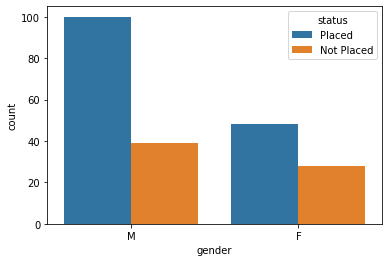

In [9]:
plt.figure()
sns.countplot(data.gender,hue=data.status)
plt.show()

* We see that there are 139 males and 67 females in total and placement of female candidates is comparitively lower than male candidates


**Effect of secondary education board on placements**

In [10]:
data.ssc_b.value_counts()

Central    116
Others      99
Name: ssc_b, dtype: int64

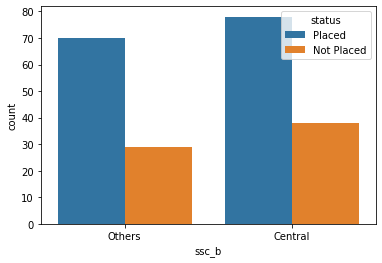

In [11]:
sns.countplot('ssc_b',hue='status',data=data)

plt.show()

* We see that there are more number of students from the central board compared to all other boards and the board of education doesn't have a significant effect on the placement status 

**Effect of Secondary Education Percentage on Placements**

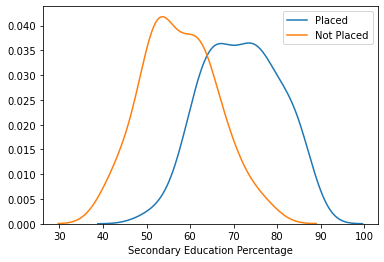

In [12]:
sns.kdeplot(data.ssc_p[data.status=='Placed'])
sns.kdeplot(data.ssc_p[data.status=='Not Placed'])
plt.legend(['Placed','Not Placed'])
plt.xlabel('Secondary Education Percentage')
plt.show()

* We see that students with higher secondary education percentage above 65 have better chances of getting placed
* Minimum percentage for a student to get placed is 50%

**Effect of Higher Education Percentage on Placements**

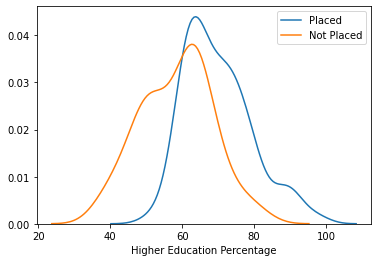

In [13]:
sns.kdeplot(data.hsc_p[data.status=='Placed'])
sns.kdeplot(data.hsc_p[data.status=='Not Placed'])
plt.legend(['Placed','Not Placed'])
plt.xlabel('Higher Education Percentage')
plt.show()

* We see that students with better higher education percentage have better chances of getting placed
* Students having percentage above 70 get more placements while the number of students placed with percentage below 60 drops steeply 

**Effect of secondary education board on placements**

In [14]:
data.hsc_b.value_counts()

Others     131
Central     84
Name: hsc_b, dtype: int64

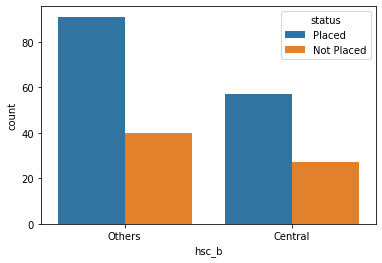

In [15]:
sns.countplot('hsc_b',hue='status',data=data)
plt.show()

* We see that most of the students are from other boards and the board of higher education doesn't effect the placements

**Effect of Specialization in higher secondary education on placements**

In [16]:
data.hsc_s.value_counts()

Commerce    113
Science      91
Arts         11
Name: hsc_s, dtype: int64

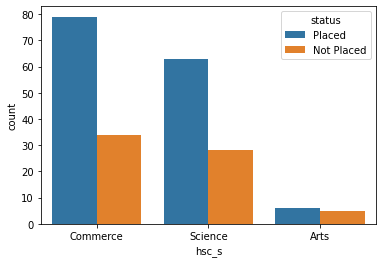

In [17]:
sns.countplot('hsc_s',hue='status',data=data)
plt.show()

* We see that the most common branch is Commerce and least common branch is Arts
* Approximately 69% of the total commerce students are placed
* Approximately 71% of the total science students are placed 
* Approximately 45% of the total arts students are NOT placed
* We conclude that science and commerce branch students have better chance at getting placed than arts students

**Effect of Degree Percentage on placements**

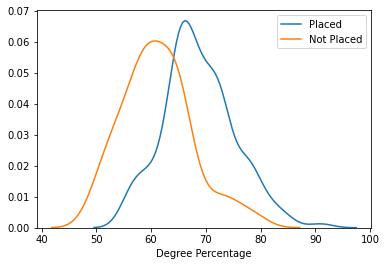

In [18]:
sns.kdeplot(data.degree_p[data.status=='Placed'])
sns.kdeplot(data.degree_p[data.status=='Not Placed'])
plt.legend(['Placed','Not Placed'])
plt.xlabel('Degree Percentage')
plt.show()

* More placements for students with percentage above 65
* Students should have a minimum of 50% to get placed

**Effect of degree type on placements**

In [19]:
data.degree_t.value_counts()

Comm&Mgmt    145
Sci&Tech      59
Others        11
Name: degree_t, dtype: int64

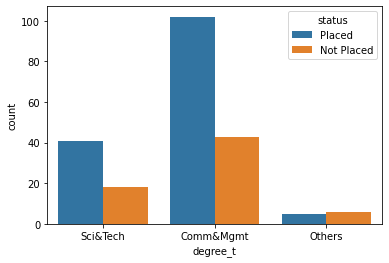

In [20]:
sns.countplot('degree_t',hue='status',data=data)
plt.show()

* We see that most of the students have opted for Commerce and Management
* Students of Science and Commerce are more likely to be placed as compared to other branches

 **Effect of Work experience on placements**

In [21]:
data.workex.value_counts()

No     141
Yes     74
Name: workex, dtype: int64

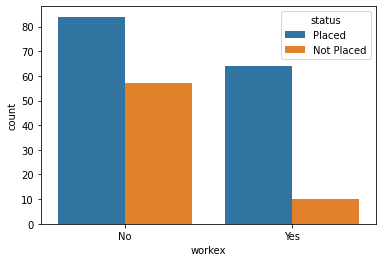

In [22]:
sns.countplot('workex',hue='status',data=data)
plt.show()

* Students with higher work experience are more likely to get placed

**Effect of Employability test percentage on placement**

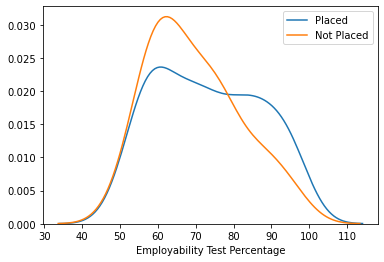

In [23]:
sns.kdeplot(data.etest_p[data.status=='Placed'])
sns.kdeplot(data.etest_p[data.status=='Not Placed'])
plt.legend(['Placed','Not Placed'])
plt.xlabel('Employability Test Percentage')
plt.show()

* Employability test percentage does not affect the placements much
* The students with 50-75% have lesser chance of getting placed

**Effect of Post Graduation Specialization**

In [24]:
data.specialisation.value_counts()

Mkt&Fin    120
Mkt&HR      95
Name: specialisation, dtype: int64

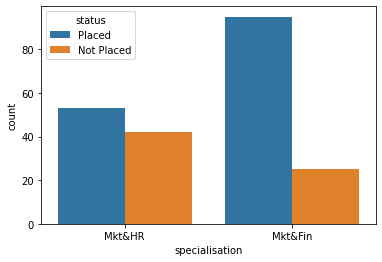

In [25]:
sns.countplot('specialisation',hue='status',data=data)
plt.show()

* The placements of Mkt&HR are lower compared to Mkt&Fin

**Effect of MBA Percentage**

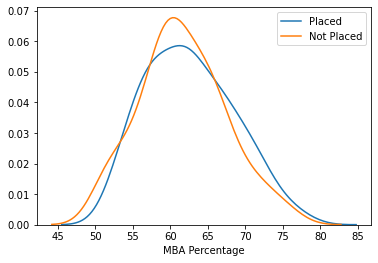

In [26]:
sns.kdeplot(data.mba_p[data.status=='Placed'])
sns.kdeplot(data.mba_p[data.status=='Not Placed'])
plt.legend(['Placed','Not Placed'])
plt.xlabel('MBA Percentage')
plt.show()

* Better MBA percentage does not guaruntee placements

# Feature Encoding
We have gender,hsc_s, degree_t, workex, specialisation, status as categorical variables 

In [27]:
data['gender']=data.gender.map({'M':0,'F':1})
data['hsc_s']=data.hsc_s.map({'Commerce':0,'Science':1,'Arts':2})
data['degree_t']=data.degree_t.map({'Comm&Mgmt':0,'Sci&Tech':1,'Others':2})
data['workex']=data.workex.map({'Yes':0,'No':1})
data['specialisation']=data.specialisation.map({'Mkt&HR':0,'Mkt&Fin':1})
data['status']=data.status.map({'Placed':1,'Not Placed':0})
data['ssc_b']=data.ssc_b.map({'Central':0,'Others':1})
data['hsc_b']=data.hsc_b.map({'Central':0,'Others':1})

In [28]:
data.head()

,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,0,67.00,1,91.00,1,0,58.00,1,1,55.0,0,58.80,1,270000.0
1,0,79.33,0,78.33,1,1,77.48,1,0,86.5,1,66.28,1,200000.0
2,0,65.00,0,68.00,0,2,64.00,0,1,75.0,1,57.80,1,250000.0
3,0,56.00,0,52.00,0,1,52.00,1,1,66.0,0,59.43,0,NaN
4,0,85.80,0,73.60,0,0,73.30,0,1,96.8,1,55.50,1,425000.0


Coorelation between the features

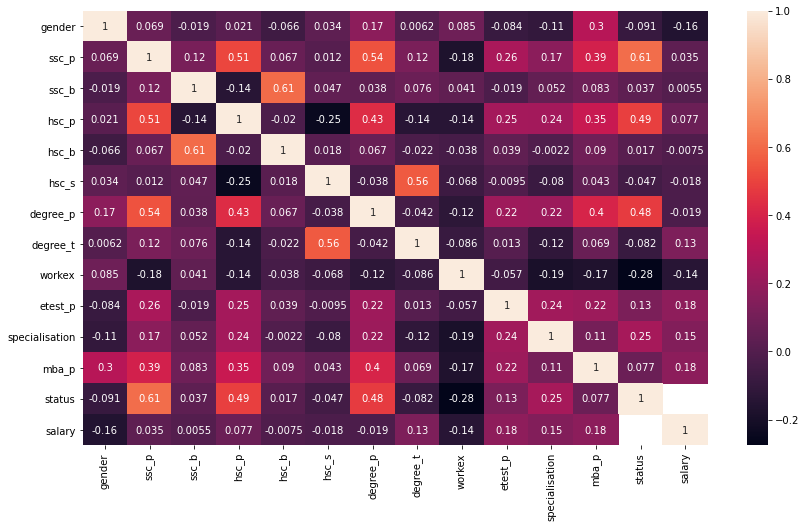

In [29]:
cor=data.corr()
plt.figure(figsize=(14,8))
sns.heatmap(cor,annot=True)

In [30]:
features=['gender','ssc_b','ssc_p','hsc_p','hsc_b','hsc_s','degree_p','degree_t','workex','etest_p','specialisation','mba_p']
X=data[features]
y=data['status']
from sklearn.metrics import accuracy_score,roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=0,test_size=0.3)
scaler=StandardScaler()
X_train_sc=scaler.fit_transform(X_train)
X_test_sc=scaler.transform(X_test)

In [31]:
from sklearn.linear_model import LogisticRegression
clf=LogisticRegression()
clf.fit(X_train_sc,y_train)
predictions=clf.predict(X_test_sc)
score=accuracy_score(y_test,predictions)
score

0.8615384615384616

In [32]:
from sklearn.svm import SVC
clf=SVC()
clf.fit(X_train_sc,y_train)
predictions=clf.predict(X_test_sc)
score=accuracy_score(y_test,predictions)
score

0.8307692307692308

In [33]:
from sklearn.tree import DecisionTreeClassifier
tree=DecisionTreeClassifier(random_state=0)
tree.fit(X_train_sc,y_train)
predictions=tree.predict(X_test_sc)
score=accuracy_score(y_test,predictions)
score

0.7538461538461538

In [34]:
from sklearn.ensemble import RandomForestClassifier
rfclf=RandomForestClassifier(random_state=0,n_estimators=100)
rfclf.fit(X_train_sc,y_train)
predictions=rfclf.predict(X_test_sc)
score=accuracy_score(y_test,predictions)
score

0.7692307692307693

In [35]:
from sklearn.neighbors import KNeighborsClassifier
model=KNeighborsClassifier()
model.fit(X_train_sc,y_train)
predictions=model.predict(X_test_sc)
score=accuracy_score(y_test,predictions)
score

0.8461538461538461

In [36]:
from sklearn.naive_bayes import GaussianNB
model=GaussianNB()
model.fit(X_train_sc,y_train)
predictions=model.predict(X_test_sc)
score=accuracy_score(y_test,predictions)
score

0.8153846153846154

We get a maximum accuracy of 86% using Logisitc Regression